## ORIGINAL CODE FROM ROY

In [23]:
import cv2
import os
import numpy as np

# ====== CONFIG ======
input_root  = r"Before"
output_root = r"After"
size = (90, 90)

# Load detectors
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

os.makedirs(output_root, exist_ok=True)


# ── Helper: normalize lighting ─────────────────────────────────────
def normalize_lighting(gray):
    clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img  = clahe.apply(gray)
    normalized = cv2.normalize(clahe_img, None, 0, 255, cv2.NORM_MINMAX)
    return normalized


# ── Helper: align face using eyes ──────────────────────────────────
def align_face(gray, x, y, w, h):
    face_roi = gray[y : y + h//2, x : x + w]
    eyes = eye_cascade.detectMultiScale(
        face_roi,
        scaleFactor=1.1,
        minNeighbors=8,
        minSize=(20, 20),
        maxSize=(w//3, h//3)
    )

    if len(eyes) < 2:
        return gray, x, y, w, h

    eyes = sorted(eyes, key=lambda e: e[2] * e[3], reverse=True)[:2]
    eyes = sorted(eyes, key=lambda e: e[0])

    (ex1, ey1, ew1, eh1) = eyes[0]
    (ex2, ey2, ew2, eh2) = eyes[1]

    left_eye_center  = (int(x + ex1 + ew1 // 2), int(y + ey1 + eh1 // 2))
    right_eye_center = (int(x + ex2 + ew2 // 2), int(y + ey2 + eh2 // 2))

    eye_height_diff = abs(left_eye_center[1] - right_eye_center[1])
    if eye_height_diff > h * 0.15:
        print(f"    ↳ Eye height mismatch, skipping rotation")
        return gray, x, y, w, h

    eye_width_gap = abs(left_eye_center[0] - right_eye_center[0])
    if eye_width_gap < w * 0.2:
        print(f"    ↳ Eyes too close together, skipping rotation")
        return gray, x, y, w, h

    dx    = right_eye_center[0] - left_eye_center[0]
    dy    = right_eye_center[1] - left_eye_center[1]
    angle = np.degrees(np.arctan2(dy, dx))

    if abs(angle) > 30:
        print(f"    ↳ Rotation angle too large ({angle:.1f}°), skipping")
        return gray, x, y, w, h

    eye_mid = (
        int((left_eye_center[0] + right_eye_center[0]) // 2),
        int((left_eye_center[1] + right_eye_center[1]) // 2)
    )

    M       = cv2.getRotationMatrix2D(eye_mid, angle, 1.0)
    aligned = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)
    return aligned, x, y, w, h


# ── Main loop ──────────────────────────────────────────────────────
total_success = 0
total_fail    = 0
total_no_eyes = 0

for person_name in os.listdir(input_root):
    person_input_path  = os.path.join(input_root,  person_name)
    person_output_path = os.path.join(output_root, person_name)

    if not os.path.isdir(person_input_path):
        continue

    os.makedirs(person_output_path, exist_ok=True)
    print(f"\n📁 Processing: {person_name}")

    success_count = 0
    fail_count    = 0
    no_eye_count  = 0

    for filename in os.listdir(person_input_path):
        img_path = os.path.join(person_input_path, filename)
        img      = cv2.imread(img_path)

        if img is None:
            print(f"  Could not read: {filename}")
            continue

        h_img, w_img = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ── 1. Detect face ──────────────────────────────────────────
        faces = []
        for scale in [1.05, 1.1, 1.15, 1.2]:
            detected = face_cascade.detectMultiScale(
                gray,
                scaleFactor=scale,
                minNeighbors=4,
                minSize=(40, 40)
            )
            if len(detected) > 0:
                faces = detected
                break

        if len(faces) == 0:
            print(f"  ✗ No face detected: {filename}")
            fail_count += 1
            continue

        # ── 2. Take the largest face ────────────────────────────────
        faces = sorted(faces, key=lambda r: r[2] * r[3], reverse=True)
        (x, y, w, h) = faces[0]

        # ── 3. Eye alignment + rotation ─────────────────────────────
        aligned_gray, x, y, w, h = align_face(gray, x, y, w, h)

        if aligned_gray is gray:
            print(f"  ⚠ No eyes found (skipping rotation): {filename}")
            no_eye_count += 1

        # ── 4. Tight Olivetti-style crop ────────────────────────────
        forehead_extra = int(h * 0.15)
        chin_extra     = int(h * 0.05)
        side_extra     = int(w * 0.0)

        x1 = max(0, x - side_extra)
        y1 = max(0, y - forehead_extra)
        x2 = min(w_img, x + w + side_extra)
        y2 = min(h_img, y + h + chin_extra)

        face_crop = aligned_gray[y1:y2, x1:x2]

        if face_crop.size == 0:
            print(f"  ✗ Empty crop: {filename}")
            fail_count += 1
            continue

        # ── 5. Resize ───────────────────────────────────────────────
        resized = cv2.resize(face_crop, size, interpolation=cv2.INTER_AREA)

        # ── 6. Lighting normalization ───────────────────────────────
        normalized = normalize_lighting(resized)

        # ── 7. Save ─────────────────────────────────────────────────
        output_path = os.path.join(person_output_path, filename)
        cv2.imwrite(output_path, normalized)
        print(f"  ✓ {filename}")
        success_count += 1

    print(f"  → Done: {success_count} saved | {fail_count} failed | {no_eye_count} no eyes (still saved)")
    total_success += success_count
    total_fail    += fail_count
    total_no_eyes += no_eye_count

print(f"\n{'='*40}")
print(f"Total success: {total_success} | Failed: {total_fail} | No eyes (still saved): {total_no_eyes}")


📁 Processing: Fazil
  ⚠ No eyes found (skipping rotation): IMG_3293.jpg
  ✓ IMG_3293.jpg
  ✓ IMG_3241.png
  Could not read: .DS_Store
  ✓ IMG_3297.jpg
  ✓ IMG_3242.jpg
    ↳ Eyes too close together, skipping rotation
  ⚠ No eyes found (skipping rotation): IMG_3294.jpg
  ✓ IMG_3294.jpg
  ✓ IMG_3233.jpg
  ⚠ No eyes found (skipping rotation): IMG_3236.jpg
  ✓ IMG_3236.jpg
  ⚠ No eyes found (skipping rotation): IMG_3237.jpg
  ✓ IMG_3237.jpg
  ✓ IMG_3235.jpg
  ✓ IMG_3234.jpg
  ⚠ No eyes found (skipping rotation): IMG_3238.png
  ✓ IMG_3238.png
  ✓ IMG_3298.jpg
  → Done: 12 saved | 0 failed | 5 no eyes (still saved)

📁 Processing: Fathiah
  Could not read: .DS_Store
  ⚠ No eyes found (skipping rotation): img9.png
  ✓ img9.png
  ⚠ No eyes found (skipping rotation): img8.png
  ✓ img8.png
  ⚠ No eyes found (skipping rotation): img5.jpg
  ✓ img5.jpg
  ⚠ No eyes found (skipping rotation): img4.jpg
  ✓ img4.jpg
  ⚠ No eyes found (skipping rotation): img6.jpg
  ✓ img6.jpg
  ✓ img7.jpg
  ⚠ No eyes f

## + TO SAVE .NPY FILES

In [24]:
import cv2
import os
import numpy as np

# ====== CONFIG ======
input_root  = r"Before"
output_root = r"After"
size = (90, 90)  # change to (64, 64) for Olivetti-style

# Load detectors
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

os.makedirs(output_root, exist_ok=True)

# ==============================
# DATA STORAGE (NEW)
# ==============================
all_faces = []
all_labels = []
label_names = []
label_map = {}
current_label = 0


# ── Helper: normalize lighting ─────────────────────────────────────
def normalize_lighting(gray):
    clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img  = clahe.apply(gray)
    normalized = cv2.normalize(clahe_img, None, 0, 255, cv2.NORM_MINMAX)
    return normalized


# ── Helper: align face using eyes ──────────────────────────────────
def align_face(gray, x, y, w, h):
    face_roi = gray[y : y + h//2, x : x + w]
    eyes = eye_cascade.detectMultiScale(
        face_roi,
        scaleFactor=1.1,
        minNeighbors=8,
        minSize=(20, 20),
        maxSize=(w//3, h//3)
    )

    if len(eyes) < 2:
        return gray, x, y, w, h

    eyes = sorted(eyes, key=lambda e: e[2] * e[3], reverse=True)[:2]
    eyes = sorted(eyes, key=lambda e: e[0])

    (ex1, ey1, ew1, eh1) = eyes[0]
    (ex2, ey2, ew2, eh2) = eyes[1]

    left_eye_center  = (int(x + ex1 + ew1 // 2), int(y + ey1 + eh1 // 2))
    right_eye_center = (int(x + ex2 + ew2 // 2), int(y + ey2 + eh2 // 2))

    eye_height_diff = abs(left_eye_center[1] - right_eye_center[1])
    if eye_height_diff > h * 0.15:
        return gray, x, y, w, h

    eye_width_gap = abs(left_eye_center[0] - right_eye_center[0])
    if eye_width_gap < w * 0.2:
        return gray, x, y, w, h

    dx    = right_eye_center[0] - left_eye_center[0]
    dy    = right_eye_center[1] - left_eye_center[1]
    angle = np.degrees(np.arctan2(dy, dx))

    if abs(angle) > 30:
        return gray, x, y, w, h

    eye_mid = (
        int((left_eye_center[0] + right_eye_center[0]) // 2),
        int((left_eye_center[1] + right_eye_center[1]) // 2)
    )

    M       = cv2.getRotationMatrix2D(eye_mid, angle, 1.0)
    aligned = cv2.warpAffine(
        gray, M, (gray.shape[1], gray.shape[0]),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return aligned, x, y, w, h


# ── Main loop ──────────────────────────────────────────────────────
total_success = 0
total_fail    = 0
total_no_eyes = 0

for person_name in os.listdir(input_root):
    person_input_path  = os.path.join(input_root,  person_name)
    person_output_path = os.path.join(output_root, person_name)

    if not os.path.isdir(person_input_path):
        continue

    # ===== LABEL ASSIGNMENT (NEW) =====
    if person_name not in label_map:
        label_map[person_name] = current_label
        label_names.append(person_name)
        current_label += 1

    label_id = label_map[person_name]

    os.makedirs(person_output_path, exist_ok=True)
    print(f"\n📁 Processing: {person_name}")

    success_count = 0
    fail_count    = 0
    no_eye_count  = 0

    for filename in os.listdir(person_input_path):
        img_path = os.path.join(person_input_path, filename)
        img      = cv2.imread(img_path)

        if img is None:
            continue

        h_img, w_img = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ── 1. Detect face ──────────────────────────────────────────
        faces = []
        for scale in [1.05, 1.1, 1.15, 1.2]:
            detected = face_cascade.detectMultiScale(
                gray,
                scaleFactor=scale,
                minNeighbors=4,
                minSize=(40, 40)
            )
            if len(detected) > 0:
                faces = detected
                break

        if len(faces) == 0:
            fail_count += 1
            continue

        # ── 2. Take largest face ────────────────────────────────────
        faces = sorted(faces, key=lambda r: r[2] * r[3], reverse=True)
        (x, y, w, h) = faces[0]

        # ── 3. Align ────────────────────────────────────────────────
        aligned_gray, x, y, w, h = align_face(gray, x, y, w, h)

        if aligned_gray is gray:
            no_eye_count += 1

        # ── 4. Crop ─────────────────────────────────────────────────
        forehead_extra = int(h * 0.15)
        chin_extra     = int(h * 0.05)

        x1 = max(0, x)
        y1 = max(0, y - forehead_extra)
        x2 = min(w_img, x + w)
        y2 = min(h_img, y + h + chin_extra)

        face_crop = aligned_gray[y1:y2, x1:x2]

        if face_crop.size == 0:
            fail_count += 1
            continue

        # ── 5. Resize ───────────────────────────────────────────────
        resized = cv2.resize(face_crop, size, interpolation=cv2.INTER_AREA)

        # ── 6. Normalize ────────────────────────────────────────────
        normalized = normalize_lighting(resized)

        # ===== STORE DATA (NEW) =====
        face_array = normalized.astype("float32") / 255.0
        all_faces.append(face_array)
        all_labels.append(label_id)

        # ── 7. Save image ───────────────────────────────────────────
        output_path = os.path.join(person_output_path, filename)
        cv2.imwrite(output_path, normalized)

        success_count += 1

    print(f"  → Done: {success_count} saved | {fail_count} failed | {no_eye_count} no eyes")
    total_success += success_count
    total_fail    += fail_count
    total_no_eyes += no_eye_count


print(f"\n{'='*40}")
print(f"Total success: {total_success} | Failed: {total_fail} | No eyes: {total_no_eyes}")


# ==============================
# SAVE DATASET (NEW)
# ==============================
X = np.array(all_faces)
y = np.array(all_labels)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

if len(X) > 0:
    np.save("faces.npy", X)
    np.save("labels.npy", y)
    np.save("label_names.npy", np.array(label_names))

    # Optional flattened version
    X_flat = X.reshape(len(X), -1)
    np.save("faces_flat.npy", X_flat)

    print("✅ Saved faces.npy, labels.npy, label_names.npy")
else:
    print("❌ No data to save")


📁 Processing: Fazil
  → Done: 12 saved | 0 failed | 5 no eyes

📁 Processing: Fathiah
  → Done: 15 saved | 0 failed | 13 no eyes

📁 Processing: roy
  → Done: 14 saved | 1 failed | 7 no eyes

📁 Processing: Mikail 
  → Done: 13 saved | 1 failed | 12 no eyes

📁 Processing: Joe
  → Done: 15 saved | 0 failed | 10 no eyes

📁 Processing: Syarah
  → Done: 15 saved | 0 failed | 6 no eyes

📁 Processing: Jasper
  → Done: 16 saved | 0 failed | 5 no eyes

Total success: 100 | Failed: 2 | No eyes: 58
Dataset shape: (100, 90, 90)
Labels shape: (100,)
✅ Saved faces2.npy, labels2.npy, label_names2.npy


## IMAGES APPEAR AS OLIVETTI DATASET

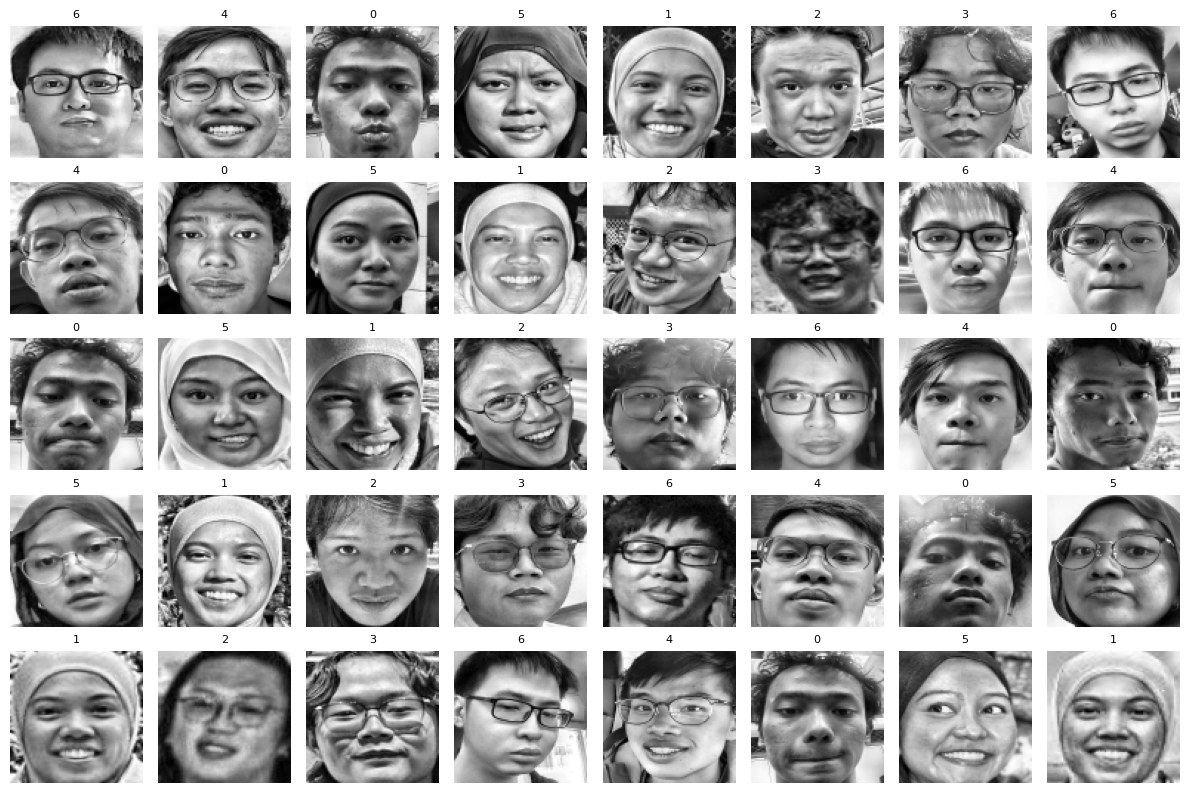

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Load data
X = np.load("faces.npy")      # (N, 64, 64)
y = np.load("labels.npy")     # (N,)

def show_balanced_faces(X, y, rows=5, cols=8):
    # Group indices by person
    person_dict = defaultdict(list)
    for idx, label in enumerate(y):
        person_dict[label].append(idx)

    # Shuffle within each person
    for label in person_dict:
        np.random.shuffle(person_dict[label])

    # Get all persons and shuffle their order
    persons = list(person_dict.keys())
    np.random.shuffle(persons)

    selected_indices = []

    # Round-robin pick (ensures everyone appears)
    while len(selected_indices) < rows * cols:
        added = False

        for person in persons:
            if person_dict[person]:
                selected_indices.append(person_dict[person].pop())
                added = True

                if len(selected_indices) >= rows * cols:
                    break

        if not added:
            break  # no more images left

    # Plot
    fig, axes = plt.subplots(rows, cols, figsize=(12, 8))

    for i, ax in enumerate(axes.flat):
        if i < len(selected_indices):
            idx = selected_indices[i]
            ax.imshow(X[idx], cmap="gray")
            ax.set_title(y[idx], fontsize=8)

        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Run
show_balanced_faces(X, y)